# Phase 5 — Product Recommendation Model

**Group 19 · Owner: Data Lead**

Predicts the **product a customer would buy from their social profile** — i.e. before the
purchase. Only the social features are legitimate inputs; transaction columns (amount,
rating, date) are post-purchase leakage and are excluded (see `merge_and_clean` roles).

| role | columns |
|---|---|
| **predictors** | `avg_engagement`, `avg_purchase_interest`, `n_platforms`, `primary_platform`, `dominant_sentiment` |
| **target** | `product_category` |
| **excluded (leakage)** | `purchase_date`, `purchase_amount`, `customer_rating` |

The reproducible logic lives in `scripts/train_product_model.py`; this notebook shows the
reasoning and the honest evaluation.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
from sklearn.model_selection import StratifiedGroupKFold

sns.set_theme(style="whitegrid")
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "scripts"))
import merge_and_clean as mc
import train_product_model as tpm

FIG = ROOT / "results" / "figures"; FIG.mkdir(parents=True, exist_ok=True)
df = pd.read_csv(ROOT / "data" / "processed" / "merged_dataset.csv")
classes = sorted(df[mc.TARGET].unique())
print(df.shape, "| predictors:", mc.PREDICTORS)

(117, 11) | predictors: ['avg_engagement', 'avg_purchase_interest', 'n_platforms', 'primary_platform', 'dominant_sentiment']


## 1. Target & class balance

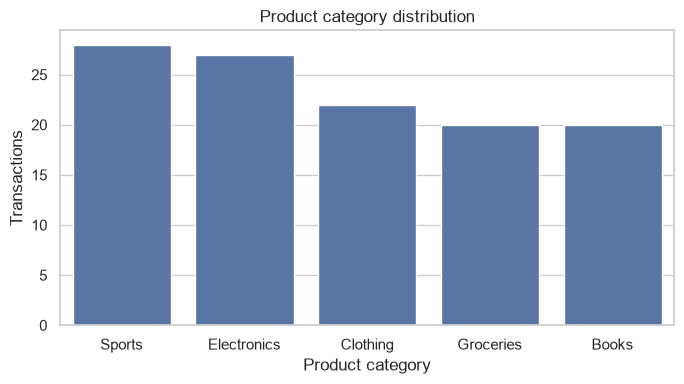

product_category
Sports         28
Electronics    27
Clothing       22
Groceries      20
Books          20
Name: count, dtype: int64

In [2]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.countplot(data=df, x=mc.TARGET, order=df[mc.TARGET].value_counts().index, ax=ax)
ax.set_title("Product category distribution"); ax.set_xlabel("Product category"); ax.set_ylabel("Transactions")
fig.tight_layout(); fig.savefig(FIG / "p5_class_balance.png", dpi=120); plt.show()
df[mc.TARGET].value_counts()

## 2. Why the split must group by customer *(the leakage trap)*

The rows are per **transaction**, but each customer's social features are **identical
across all their transactions**. So a plain row split can place the same customer in both
train and test — the model then "recognises" a customer it has already seen instead of
generalising. We group the split by `customer_id` (StratifiedGroupKFold), exactly as
Phases 3–4 grouped by source image / clip.

In [3]:
cats = df.groupby("customer_id")[mc.TARGET].nunique()
print("transactions:", len(df), "| unique customers:", df.customer_id.nunique())
print("customers buying 1 category:", int((cats == 1).sum()),
      "| more than one:", int((cats > 1).sum()))

transactions: 117 | unique customers: 61
customers buying 1 category: 31 | more than one: 30


**Interpretation.** 117 transactions come from only 61 customers, and **30 of them buy
more than one category**. Because the predictors are customer-level, those 30 customers map
one identical feature vector to several different products — an *irreducible* ceiling on
accuracy that no model can cross. Grouping by customer also makes the score honest:
we test on customers never seen in training.

## 3. Model selection (customer-grouped CV)

In [4]:
def grouped_acc_f1(clf):
    X, y, g = df[mc.PREDICTORS], df[mc.TARGET].to_numpy(), df["customer_id"].to_numpy()
    a, f = [], []
    for tr, te in StratifiedGroupKFold(5, shuffle=True, random_state=42).split(X, y, g):
        from sklearn.pipeline import Pipeline
        pipe = Pipeline([("pre", tpm.make_pipeline().named_steps["pre"]), ("clf", clf)])
        pipe.fit(X.iloc[tr], y[tr]); pred = pipe.predict(X.iloc[te])
        a.append(accuracy_score(y[te], pred))
        f.append(f1_score(y[te], pred, average="macro", labels=classes, zero_division=0))
    return np.mean(a), np.std(a), np.mean(f)

rows = []
for name, clf in [("majority baseline", DummyClassifier(strategy="most_frequent")),
                  ("LogReg (C=0.2)", LogisticRegression(C=0.2, max_iter=5000, random_state=42)),
                  ("RandomForest", RandomForestClassifier(n_estimators=300, max_depth=4, random_state=42))]:
    acc_m, acc_s, f1_m = grouped_acc_f1(clf)
    rows.append({"model": name, "accuracy": round(acc_m, 3), "acc_std": round(acc_s, 3), "macro_f1": round(f1_m, 3)})
pd.DataFrame(rows)

,model,accuracy,acc_std,macro_f1
0,majority baseline,0.222,0.014,0.073
1,LogReg (C=0.2),0.231,0.021,0.174
2,RandomForest,0.221,0.065,0.176


**Interpretation.** The regularised **LogisticRegression (C=0.2)** gives the best accuracy
(marginally above the majority baseline) and the most stable folds, while lifting macro-F1
well above the baseline's — it actually spreads predictions across classes rather than always
guessing the biggest one. On this tiny, mostly-categorical data a strong non-linear model
(RandomForest / XGBoost) overfits and does no better, so we keep the simple linear model.

## 4. Honest evaluation & the leakage contrast

In [5]:
summary, folds = tpm.grouped_cv(df, classes)
print("grouped CV (unseen customers):")
for k, v in summary.items(): print(f"  {k:16s} {v}")
print("majority baseline acc :", tpm.baseline_accuracy(df))
print("leaky row-split acc   :", tpm.leaky_rowsplit_accuracy(df), "(inflated / dishonest)")
pd.DataFrame(folds)

grouped CV (unseen customers):
  accuracy_mean    0.2308
  accuracy_std     0.0207
  f1_macro_mean    0.1739
  f1_macro_std     0.0269
  log_loss_mean    1.6955
  log_loss_std     0.0916
majority baseline acc : 0.2221
leaky row-split acc   : 0.2402 (inflated / dishonest)


,fold,accuracy,f1_macro,log_loss,test_customers,test_rows
0,1,0.2083,0.2108,1.7781,13,24
1,2,0.2500,0.1475,1.5353,12,24
2,3,0.2174,0.2024,1.7492,12,23
3,4,0.2174,0.1527,1.6514,13,23
4,5,0.2609,0.1563,1.7636,11,23


**Interpretation.** Honest accuracy is ~0.23 (≈ the 0.22 majority baseline) with macro-F1
~0.17 (vs a dummy's 0.07). The leaky row-split reads only slightly higher here — not because
the split is safe, but because the task is *so* hard that even seeing a customer barely helps
predict their other, different purchases. Grouping is still the correct methodology; we report
the grouped number.

## 5. Confusion matrix (out-of-fold)

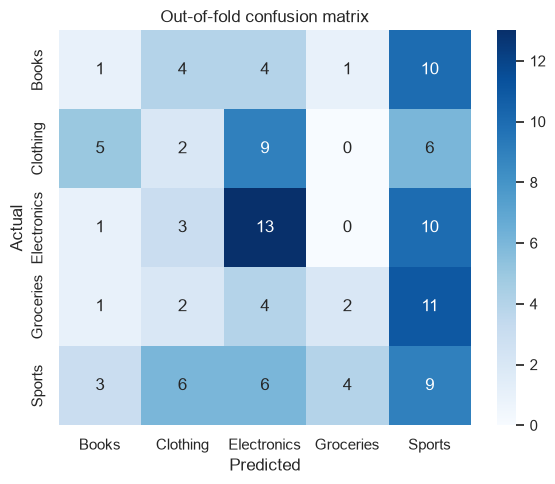

In [6]:
X, y, g = df[mc.PREDICTORS], df[mc.TARGET].to_numpy(), df["customer_id"].to_numpy()
oof = np.empty(len(df), dtype=object)
for tr, te in StratifiedGroupKFold(5, shuffle=True, random_state=42).split(X, y, g):
    oof[te] = tpm.make_pipeline().fit(X.iloc[tr], y[tr]).predict(X.iloc[te])
cm = confusion_matrix(y, oof, labels=classes)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes, ax=ax)
ax.set_title("Out-of-fold confusion matrix"); ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
fig.tight_layout(); fig.savefig(FIG / "p5_confusion_matrix.png", dpi=120, bbox_inches="tight"); plt.show()

**Interpretation.** Predictions scatter across the diagonal and off it — the model has
genuine but weak discrimination. No single class dominates the predictions (unlike the
baseline, which would fill one column), which is why macro-F1 beats the baseline even though
raw accuracy barely does.

## 6. Accuracy vs baseline

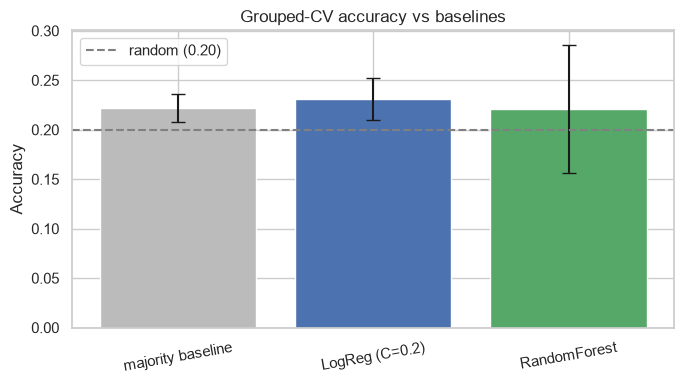

In [7]:
comp = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(comp["model"], comp["accuracy"], yerr=comp["acc_std"], capsize=5,
       color=["#bbb", "#4c72b0", "#55a868"])
ax.axhline(1/len(classes), ls="--", color="grey", label=f"random ({1/len(classes):.2f})")
ax.set_title("Grouped-CV accuracy vs baselines"); ax.set_ylabel("Accuracy"); ax.legend()
plt.xticks(rotation=10)
fig.tight_layout(); fig.savefig(FIG / "p5_model_vs_baseline.png", dpi=120, bbox_inches="tight"); plt.show()

## 7. Member → customer mapping (for Phase 6)

The four team members are not customers, so Phase 6 needs a fixed mapping from a recognised
face to a tabular record. `train_product_model` assigns each member a real customer with a
distinct predicted product, saved inside `models/product_model.joblib`.

In [8]:
demo = tpm.member_demo_records(df, tpm.make_pipeline().fit(df[mc.PREDICTORS], df[mc.TARGET]))
pd.DataFrame([{"member": m, "customer_id": r["customer_id"], "predicted_product": r["predicted_product"]}
             for m, r in demo.items()])

,member,customer_id,predicted_product
0,Gentil_Tonny_Christian_Iradukunda,100,Electronics
1,Hassan_Adelani_Luqman,101,Sports
2,Mahlet_Assefa_Tilahun,104,Clothing
3,Yvette_Uwimpaye,141,Groceries


## 8. Limitations & takeaways

- **Weak by nature, not by tuning.** Customer-level features + 30/61 customers buying several
  categories cap accuracy near the majority baseline; the win is in macro-F1.
- **Methodology is the headline.** The customer-grouped split is what makes the number
  trustworthy — a row split would look better but be dishonest.
- **What would help:** per-visit / per-session context (which platform the customer is on *now*,
  time, browsing signal), not more model complexity.
- **Artifacts:** `models/product_model.joblib` (+ member mapping) and
  `results/metrics/product_recommendation.json`. Ready for the Phase 6 CLI.